# 실습 9: 혼동행렬과 분류 결과 리포트
- 상황: 정확도 하나로는 어느 모델이 나은지 답할 수 없다
- 목표: 틀린 것을 두 종류로 나눠 보고, 오늘 결과를 리포트 한 장으로 마감한다

## Step 0. 앞 실습까지 재현하기

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. 정제본 불러오기 (day02 실습 결과물)
df = pd.read_csv("../../day02/lab06_clean-dataset/results/secom_clean.csv")

# 2. 센서 열의 빈칸을 그 열의 중앙값으로 채우기
센서열 = [c for c in df.columns if c.startswith("sensor_")]
df[센서열] = df[센서열].fillna(df[센서열].median())

# 3. 판정을 숫자로 — 불량이면 1, 아니면 0
df["불량여부"] = (df["result"] == "불량").astype(int)

# 4. 입력은 센서 열만, 정답은 불량여부
X = df[센서열]
y = df["불량여부"]

# 5. 학습용과 시험용으로 나누기 (불량 비율을 양쪽에 맞춰서)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. 표준화 후 로지스틱 회귀 — 불균형 보정 설정은 넣지 않는다
자 = StandardScaler()
X_train_표준 = 자.fit_transform(X_train)   # 기준은 학습용에서만 배운다
X_test_표준 = 자.transform(X_test)         # 시험용은 그 기준을 적용만

모델 = LogisticRegression(max_iter=1000)
모델.fit(X_train_표준, y_train)
예측 = 모델.predict(X_test_표준)

정확도 = (예측 == y_test).mean()

print("학습용:", len(X_train), "건 (불량", int((y_train == 1).sum()), "건)")
print("시험용:", len(X_test), "건 (불량", int((y_test == 1).sum()), "건)")
print("정확도:", round(정확도 * 100, 2), "%")

학습용: 1253 건 (불량 83 건)
시험용: 314 건 (불량 21 건)
정확도: 93.95 %


## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 결과를 네 칸으로 나눠 볼 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 혼동행렬 | 맞힌 것과 틀린 것을 네 칸으로 나눠 놓은 표 |
| 놓친 불량 | 불량인데 양품이라 한 것. 걸러지지 않고 고객에게 간다 |
| 헛경보 | 양품인데 불량이라 한 것. 멀쩡한 것을 세워 다시 본다 |
| 재현율 (recall) | 실제 불량 중 몇 %를 잡았나 |
| 정밀도 (precision) | 불량이라 한 것 중 진짜가 몇 %였나 |
| F1 | 재현율과 정밀도를 함께 보는 값. 한쪽만 좋으면 오르지 않는다 |

## Step 2. 네 칸으로 쪼개기

In [2]:
# confusion_matrix - 실제 답과 예측을 맞대어 네 칸으로 세어준다
from sklearn.metrics import confusion_matrix

행렬 = confusion_matrix(y_test, 예측)
print(행렬)

# ravel() - 네 칸을 한 줄로 펴서 하나씩 이름을 붙여 받는다
# 순서가 정해져 있다: 왼쪽위, 오른쪽위, 왼쪽아래, 오른쪽아래
맞힌양품, 헛경보, 놓친불량, 잡은불량 = 행렬.ravel()

print("양품인데 양품이라 함 :", 맞힌양품)
print("양품인데 불량이라 함 :", 헛경보,   " <- 헛경보")
print("불량인데 양품이라 함 :", 놓친불량, " <- 놓친 불량")
print("불량인데 불량이라 함 :", 잡은불량)

[[293   0]
 [ 19   2]]
양품인데 양품이라 함 : 293
양품인데 불량이라 함 : 0  <- 헛경보
불량인데 양품이라 함 : 19  <- 놓친 불량
불량인데 불량이라 함 : 2


## Step 3. 네 칸이 현장에서 무슨 상황인가

| 칸 | 내 숫자 | 현장에서는 |
|---|---|---|
| 양품인데 양품 | [293] | 아무 일 없음 |
| 양품인데 불량 (헛경보) | [0] | 멀쩡한 걸 세우고 다시 본다. 사람 손이 든다 |
| 불량인데 양품 (놓친 불량) | [19] | 걸러지지 않고 고객에게 간다 |
| 불량인데 불량 | [2] | 원하던 것. 미리 잡았다 |

## Step 4. 두 지표를 손으로 계산하기

In [3]:
# 재현율 - 실제 불량 중 몇 %를 잡았나
# 분모는 "실제 불량 전체" = 잡은 것 + 놓친 것
재현율 = 잡은불량 / (잡은불량 + 놓친불량)

# 정밀도 - 불량이라 한 것 중 진짜가 몇 %였나
# 분모는 "불량이라고 한 것 전체" = 진짜 + 헛경보
정밀도 = 잡은불량 / (잡은불량 + 헛경보)

print("재현율:", round(재현율, 3), " <- 실제 불량", 잡은불량 + 놓친불량, "건 중", 잡은불량, "건")
print("정밀도:", round(정밀도, 3), " <- 불량이라 한", 잡은불량 + 헛경보, "건 중", 잡은불량, "건")

재현율: 0.095  <- 실제 불량 21 건 중 2 건
정밀도: 1.0  <- 불량이라 한 2 건 중 2 건


### 문법 노트 - 네 칸에서 지표 뽑기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| confusion_matrix(실제, 예측) | 맞고 틀림을 네 칸으로 세어준다 | 정확도 하나로는 안 보이는 걸 본다 |
| .ravel() | 네 칸을 한 줄로 펴준다 | 칸마다 이름을 붙여 받으려고 |
| classification_report | 지표를 한 번에 계산해 표로 보여준다 | 손으로 구한 값과 맞춰보려고 |

**분자는 둘 다 같고 분모가 다르다.**<br>
재현율 = 잡은불량 / (잡은불량 + 놓친불량)   분모가 "실제 불량 전체"<br>
정밀도 = 잡은불량 / (잡은불량 + 헛경보)     분모가 "불량이라 한 것 전체"<br>
헷갈리면 분모부터 정하면 된다.

## Step 5. 라이브러리 출력과 대조하기


In [4]:
from sklearn.metrics import classification_report

# target_names - 0과 1 대신 사람이 읽을 이름을 붙인다
# digits=3 - 소수점 셋째 자리까지
print(classification_report(y_test, 예측,
                            target_names=["양품", "불량"], digits=3))

              precision    recall  f1-score   support

          양품      0.939     1.000     0.969       293
          불량      1.000     0.095     0.174        21

    accuracy                          0.939       314
   macro avg      0.970     0.548     0.571       314
weighted avg      0.943     0.939     0.915       314



## Step 6. 기준 모델의 재현율은 얼마인가


In [5]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# 전부 양품(0)이라 답하는 기준 모델 — 학습은 하지 않는다
기준예측 = np.zeros(len(y_test), dtype=int)

def 재보기(이름, 답안지):
    답안지 = np.asarray(답안지)
    맞힌양품, 헛경보, 놓친불량, 잡은불량 = confusion_matrix(y_test, 답안지).ravel()
    return {
        "모델": 이름,
        "정확도(%)": round((답안지 == y_test).mean() * 100, 2),
        # zero_division=0 - 0으로 나눠야 하는 상황이면 0으로 두라는 뜻
        "재현율": round(recall_score(y_test, 답안지, zero_division=0), 3),
        "정밀도": round(precision_score(y_test, 답안지, zero_division=0), 3),
        "F1": round(f1_score(y_test, 답안지, zero_division=0), 3),
        "놓친 불량": int(놓친불량),
        "헛경보": int(헛경보),
    }

비교표 = pd.DataFrame([
    재보기("기준 모델 (전부 양품)", 기준예측),
    재보기("로지스틱 회귀", 예측),
]).set_index("모델")

print("시험용", len(y_test), "건 / 실제 불량", int((y_test == 1).sum()), "건")
print()
print("[경고가 뜨는 이유]")
print("정밀도 = 잡은불량 / (잡은불량 + 헛경보) 인데,")
print("기준 모델은 불량이라 한 것이 0건이라 분모가 0이 된다. 0으로는 나눌 수 없다.")
print("zero_division=0 을 주면 그 자리를 0으로 채우고 넘어간다.")
비교표

시험용 314 건 / 실제 불량 21 건

[경고가 뜨는 이유]
정밀도 = 잡은불량 / (잡은불량 + 헛경보) 인데,
기준 모델은 불량이라 한 것이 0건이라 분모가 0이 된다. 0으로는 나눌 수 없다.
zero_division=0 을 주면 그 자리를 0으로 채우고 넘어간다.


,정확도(%),재현율,정밀도,F1,놓친 불량,헛경보
모델,,,,,,
기준 모델 (전부 양품),93.31,0.000,0.0,0.000,21,0
로지스틱 회귀,93.95,0.095,1.0,0.174,19,0


## Step 7. 문턱을 낮춰 더 잡아보기

In [6]:
# 모델은 그대로 두고, 불량으로 판정하는 문턱만 바꿔본다
# 앞에서 만든 예측은 건드리지 않는다 (새 이름으로 만든다)

# predict_proba - 각 행이 각 쪽일 "가능성"을 돌려준다
# [:, 1] - 두 번째 열, 즉 불량(1)일 가능성만 꺼낸다
불량가능성 = 모델.predict_proba(X_test_표준)[:, 1]

print("불량 가능성 값의 범위:", round(불량가능성.min(), 4), "~", round(불량가능성.max(), 4))
print("(predict()는 이 값이 0.5를 넘으면 불량이라고 답한 것이다)")

행 = []
문턱별예측 = {}          # 문턱마다 만든 답안지를 따로 담아둔다
for 문턱 in [0.5, 0.3, 0.2, 0.1]:
    # 가능성이 문턱 이상이면 불량(1), 아니면 양품(0)
    답안지 = (불량가능성 >= 문턱).astype(int)
    문턱별예측[문턱] = 답안지

    맞힌양품, 헛경보, 놓친불량, 잡은불량 = confusion_matrix(y_test, 답안지).ravel()
    행.append({
        "문턱": 문턱,
        "잡은 불량": int(잡은불량),
        "놓친 불량": int(놓친불량),
        "헛경보": int(헛경보),
        "재현율": round(recall_score(y_test, 답안지, zero_division=0), 3),
        "정밀도": round(precision_score(y_test, 답안지, zero_division=0), 3),
    })

문턱표 = pd.DataFrame(행).set_index("문턱")

print("\n시험용", len(y_test), "건 / 실제 불량", int((y_test == 1).sum()), "건")
print("앞에서 만든 예측 그대로 — 불량이라 한 건수:", int((예측 == 1).sum()), "건")
문턱표

불량 가능성 값의 범위: 0.0002 ~ 0.9641
(predict()는 이 값이 0.5를 넘으면 불량이라고 답한 것이다)

시험용 314 건 / 실제 불량 21 건
앞에서 만든 예측 그대로 — 불량이라 한 건수: 2 건


,잡은 불량,놓친 불량,헛경보,재현율,정밀도
문턱,,,,,
0.5,2,19,0,0.095,1.000
0.3,3,18,6,0.143,0.333
0.2,5,16,13,0.238,0.278
0.1,9,12,42,0.429,0.176


### 문턱을 낮추면

| 문턱 | 잡은 불량 | 놓친 불량 | 헛경보 | 재현율 | 정밀도 |
|---|---|---|---|---|---|
| 0.5 | [2] | [19] | [0] | [0.095] | [1.000] |
| 0.3 | [3] | [18] | [6] | [0.143] | [0.333] |
| 0.2 | [5] | [16] | [13] | [0.238] | [0.278] |
| 0.1 | [9] | [12] | [42] | [0.429] | [0.176] |

## Step 8. 분류 결과 리포트 마감하기

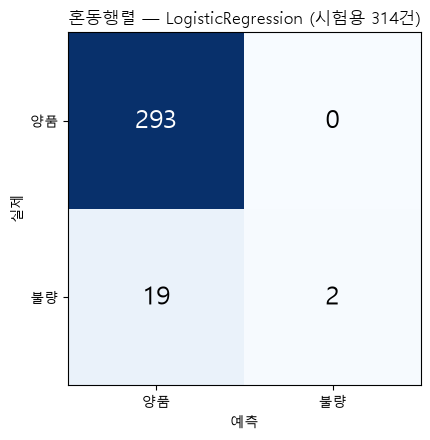

그림 저장: results\confusion_matrix.png
리포트 저장: results\report.md ( 1492 바이트 )

[저장된 report.md 와 노트북 실행값 대조]
  OK    행 수
  OK    불량 비율
  OK    학습용
  OK    시험용
  OK    기준 모델 정확도
  OK    학습 모델 한 줄
  OK    헛경보 칸
  OK    놓친 불량 칸
  OK    잡은 불량 칸
  OK    문턱 0.1 줄
  OK    그림 파일명

어긋난 항목: 0 개 


In [7]:
# 이 노트북에서 이미 계산된 값들로 그림 한 장과 리포트 한 장을 만든다
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"     # 한글이 네모로 깨지지 않게
plt.rcParams["axes.unicode_minus"] = False

저장폴더 = Path("results")
저장폴더.mkdir(exist_ok=True)

# ---------- (1) 혼동행렬 그림 ----------
그림행렬 = confusion_matrix(y_test, 예측)
칸_양품양품, 칸_헛경보, 칸_놓침, 칸_잡음 = 그림행렬.ravel()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.imshow(그림행렬, cmap="Blues")

# 네 칸에 건수를 숫자로 찍는다 (칸 색이 진하면 흰 글씨)
for i in range(2):
    for j in range(2):
        값 = int(그림행렬[i, j])
        ax.text(j, i, str(값), ha="center", va="center", fontsize=18,
                color="white" if 값 > 그림행렬.max() / 2 else "black")

ax.set_xticks([0, 1], ["양품", "불량"])
ax.set_yticks([0, 1], ["양품", "불량"])
ax.set_xlabel("예측")
ax.set_ylabel("실제")
ax.set_title(f"혼동행렬 — {type(모델).__name__} (시험용 {len(y_test)}건)")
plt.tight_layout()

그림경로 = 저장폴더 / "confusion_matrix.png"
plt.savefig(그림경로, dpi=150, bbox_inches="tight")   # show보다 먼저 저장
plt.show()
print("그림 저장:", 그림경로)

# ---------- (2) 리포트 ----------
def 지표(답안지):
    답안지 = np.asarray(답안지)
    return (
        (답안지 == y_test).mean() * 100,
        recall_score(y_test, 답안지, zero_division=0),
        precision_score(y_test, 답안지, zero_division=0),
        f1_score(y_test, 답안지, zero_division=0),
    )

기준_정확, 기준_재현, 기준_정밀, 기준_F1 = 지표(기준예측)
학습_정확, 학습_재현, 학습_정밀, 학습_F1 = 지표(예측)

줄 = ["# 분류 결과 리포트", ""]

줄 += ["## 1. 데이터", "",
       "| 항목 | 값 |", "|---|---|",
       "| 정제본 파일 | secom_clean.csv |",
       f"| 행 수 | {len(df)} |",
       f"| 열 수 (파일) | {len(센서열) + 1} (센서 {len(센서열)} + result 1) |",
       f"| 열 수 (불량여부 추가 후) | {df.shape[1]} |",
       f"| 불량 건수 | {int((y == 1).sum())} |",
       f"| 불량 비율 | {(y == 1).mean() * 100:.2f}% |",
       f"| 학습용 | {len(X_train)}건 (불량 {int((y_train == 1).sum())}건) |",
       f"| 시험용 | {len(X_test)}건 (불량 {int((y_test == 1).sum())}건) |", ""]

줄 += ["## 2. 모델", "",
       "| 항목 | 값 |", "|---|---|",
       f"| 모델 | {type(모델).__name__} (max_iter={모델.max_iter}) |",
       f"| 함께 넣은 처리 | {type(자).__name__} — 학습용에 fit, 시험용에 transform |",
       "| 빈칸 처리 | 센서 열을 그 열의 중앙값으로 채움 |",
       "| 나누기 | test_size=0.2, random_state=42, stratify=y |",
       "| 불균형 보정 | 없음 |", ""]

줄 += ["## 3. 결과 표", "",
       "| 모델 | 정확도(%) | 재현율 | 정밀도 | F1 |", "|---|---|---|---|---|",
       f"| 기준 모델 (전부 양품) | {기준_정확:.2f} | {기준_재현:.3f} | {기준_정밀:.3f} | {기준_F1:.3f} |",
       f"| {type(모델).__name__} | {학습_정확:.2f} | {학습_재현:.3f} | {학습_정밀:.3f} | {학습_F1:.3f} |", ""]

줄 += ["## 4. 혼동행렬 네 칸", "",
       "| 칸 | 건수 |", "|---|---|",
       f"| 양품인데 양품 | {int(칸_양품양품)} |",
       f"| 양품인데 불량 (헛경보) | {int(칸_헛경보)} |",
       f"| 불량인데 양품 (놓친 불량) | {int(칸_놓침)} |",
       f"| 불량인데 불량 (잡은 불량) | {int(칸_잡음)} |", ""]

줄 += ["## 5. 문턱별 비교", "",
       "| 문턱 | 잡은 불량 | 놓친 불량 | 헛경보 | 재현율 | 정밀도 |", "|---|---|---|---|---|---|"]
for 문턱, 한줄 in 문턱표.iterrows():
    줄.append(f"| {문턱} | {int(한줄['잡은 불량'])} | {int(한줄['놓친 불량'])} | "
              f"{int(한줄['헛경보'])} | {한줄['재현율']:.3f} | {한줄['정밀도']:.3f} |")
줄.append("")

줄 += ["## 6. 그림 파일", "", f"- {그림경로.name}", ""]

리포트경로 = 저장폴더 / "report.md"
리포트경로.write_text("\n".join(줄), encoding="utf-8")
print("리포트 저장:", 리포트경로, "(", 리포트경로.stat().st_size, "바이트 )")

# ---------- (3) 저장된 파일과 노트북 실행값 대조 ----------
글 = 리포트경로.read_text(encoding="utf-8")

대조 = {
    "행 수": f"| 행 수 | {len(df)} |",
    "불량 비율": f"| 불량 비율 | {(y == 1).mean() * 100:.2f}% |",
    "학습용": f"| 학습용 | {len(X_train)}건 (불량 {int((y_train == 1).sum())}건) |",
    "시험용": f"| 시험용 | {len(X_test)}건 (불량 {int((y_test == 1).sum())}건) |",
    "기준 모델 정확도": f"| 기준 모델 (전부 양품) | {기준_정확:.2f} |".replace(" |", " |", 1)[:30],
    "학습 모델 한 줄": f"| {type(모델).__name__} | {학습_정확:.2f} | {학습_재현:.3f} | {학습_정밀:.3f} | {학습_F1:.3f} |",
    "헛경보 칸": f"| 양품인데 불량 (헛경보) | {int(칸_헛경보)} |",
    "놓친 불량 칸": f"| 불량인데 양품 (놓친 불량) | {int(칸_놓침)} |",
    "잡은 불량 칸": f"| 불량인데 불량 (잡은 불량) | {int(칸_잡음)} |",
    "문턱 0.1 줄": f"| 0.1 | {int(문턱표.loc[0.1, '잡은 불량'])} | {int(문턱표.loc[0.1, '놓친 불량'])} | {int(문턱표.loc[0.1, '헛경보'])} |",
    "그림 파일명": f"- {그림경로.name}",
}

print("\n[저장된 report.md 와 노트북 실행값 대조]")
어긋남 = []
for 이름, 값 in 대조.items():
    if 값 in 글:
        print("  OK   ", 이름)
    else:
        어긋남.append(이름)
        print("  다름 ", 이름, "->", 값)

print("\n어긋난 항목:", len(어긋남), "개", 어긋남 if 어긋남 else "")

---
## 직접 해보기 (도전) - 다른 모델도 같은 문턱에서 같을까

- 상황: 한 모델로만 문턱을 옮겨봤다. 다른 모델도 같은 모양일지는 모른다
- 할 일: 앞 실습에서 추천받은 다른 모델로 같은 표를 만들어 나란히 놓는다
- 결과물: 두 모델 문턱 비교표 1개

In [8]:
# 아직 안 써본 모델(의사결정나무)로 같은 문턱 비교표를 만들어 나란히 놓는다
# 앞에서 만든 모델·예측·문턱표는 건드리지 않는다 (전부 새 이름)

from sklearn.tree import DecisionTreeClassifier

# 의사결정나무는 열마다 따로 기준선을 긋기 때문에 표준화가 필요 없다
# 그래서 표준화하지 않은 X_train을 그대로 넣는다
나무모델 = DecisionTreeClassifier(random_state=42)
나무모델.fit(X_train, y_train)

나무가능성 = 나무모델.predict_proba(X_test)[:, 1]
print("의사결정나무의 불량 가능성 값 종류:", sorted(set(나무가능성.round(4)))[:10], "...")

def 문턱표만들기(가능성):
    행 = []
    for 문턱 in [0.5, 0.3, 0.2, 0.1]:
        답안지 = (가능성 >= 문턱).astype(int)
        맞힌양품, 헛경보, 놓친불량, 잡은불량 = confusion_matrix(y_test, 답안지).ravel()
        행.append({
            "문턱": 문턱,
            "잡은 불량": int(잡은불량),
            "놓친 불량": int(놓친불량),
            "헛경보": int(헛경보),
            "재현율": round(recall_score(y_test, 답안지, zero_division=0), 3),
            "정밀도": round(precision_score(y_test, 답안지, zero_division=0), 3),
        })
    return pd.DataFrame(행).set_index("문턱")

나무문턱표 = 문턱표만들기(나무가능성)

print("\n[의사결정나무]")
print(나무문턱표)

# 두 표를 좌우로 붙인다. keys로 어느 모델 것인지 위에 표시된다
나란히 = pd.concat(
    [문턱표, 나무문턱표],
    axis=1,
    keys=["로지스틱 회귀", "의사결정나무"],
)

print("\n[두 모델 나란히]  시험용", len(y_test), "건 / 실제 불량", int((y_test == 1).sum()), "건")
print("앞에서 만든 것 그대로 — 문턱표 0.5의 잡은 불량:", int(문턱표.loc[0.5, "잡은 불량"]), "건")
나란히

의사결정나무의 불량 가능성 값 종류: [np.float64(0.0), np.float64(1.0)] ...

[의사결정나무]
     잡은 불량  놓친 불량  헛경보    재현율    정밀도
문턱                                  
0.5      5     16   26  0.238  0.161
0.3      5     16   26  0.238  0.161
0.2      5     16   26  0.238  0.161
0.1      5     16   26  0.238  0.161

[두 모델 나란히]  시험용 314 건 / 실제 불량 21 건
앞에서 만든 것 그대로 — 문턱표 0.5의 잡은 불량: 2 건


로지스틱 회귀                         의사결정나무                        
      잡은 불량 놓친 불량 헛경보    재현율    정밀도  잡은 불량 놓친 불량 헛경보    재현율    정밀도
문턱                                                                
0.5       2    19   0  0.095  1.000      5    16  26  0.238  0.161
0.3       3    18   6  0.143  0.333      5    16  26  0.238  0.161
0.2       5    16  13  0.238  0.278      5    16  26  0.238  0.161
0.1       9    12  42  0.429  0.176      5    16  26  0.238  0.161

### 두 모델의 문턱 비교 (재현율 / 정밀도)

| 문턱 | [로지스틱 회귀] | [의사결정나무] |
|---|---|---|
| 0.5 | [0.095 / 1.000] | [0.238 / 0.161] |
| 0.3 | [0.143 / 0.333] | [0.238 / 0.161] |
| 0.2 | [0.238 / 0.278] | [0.238 / 0.161] |
| 0.1 | [0.429 / 0.176] | [0.238 / 0.161] |